# Phân đoạn khuyết tật thép với Attention U-Net (Backbone ResNet18)

Notebook này trong khuôn khổ **Akbank Bootcamp**, vượt ra ngoài phân loại cổ điển để **phân đoạn khuyết tật trên bề mặt thép**.  
Người học không chỉ biết ảnh có lỗi hay không, mà còn học **vùng pixel nào bị lỗi**.

📌 Mục tiêu: bài toán **khó hơn** nhưng **học được nhiều hơn**:
- Bộ dữ liệu **Kaggle Severstal Steel Defect Detection**.
- Mask xây từ RLE trong `train.csv`.
- Mô hình **Attention U-Net (backbone ResNet18)** trên PyTorch.
- Huấn luyện **Focal Loss + Dice Loss** để xử lý mất cân bằng lớp.
- Ghi **Dice Score, Loss, LR** trong quá trình train.
- Báo cáo bằng **metric số** và **trực quan** (ảnh gốc + mask GT + dự đoán).


### 1) Cài đặt và chuẩn bị môi trường

Import thư viện, cố định `SEED` để **kết quả tái lập được**,  
và thiết lập `device` (GPU/CPU).


In [1]:
import os, gc, sys, math, random, json, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
set_seed()


### 2) Đường dẫn và cấu hình

Định nghĩa **tham số** (`CFG`) và **đường dẫn dữ liệu**:
- Kích thước ảnh (`HEIGHT`, `WIDTH`)
- Số lớp (`NUM_CLASSES`)
- Tỷ lệ train/validation (`VAL_SPLIT`)
- Batch size, epoch, learning rate, ...
- Đường dẫn (`TRAIN_CSV`, `TRAIN_DIR`, `TEST_DIR`)


In [2]:
CFG = {
    "HEIGHT": 256,
    "WIDTH": 1600,
    "NUM_CLASSES": 4,
    "VAL_SPLIT": 0.2,
    "BATCH_SIZE": 8,
    "NUM_WORKERS": 2,
    "EPOCHS": 200,
    "LR": 3e-4,
    "WEIGHT_DECAY": 1e-5,
    "PRETRAINED": True,
    "THRESHOLD": 0.5,
}

DATA_DIR = Path("../input/severstal-steel-defect-detection")
TRAIN_CSV = DATA_DIR / "train.csv"
TRAIN_DIR = DATA_DIR / "train_images"
TEST_DIR  = DATA_DIR / "test_images"       # dùng khi nộp bài (submission)
WORK_DIR  = Path("/kaggle/working")


## 3. Khám phá dữ liệu (EDA) và trực quan hóa

Phân tích **thống kê** và **biểu đồ** trên dataset:

- **Tỷ lệ ảnh có/không khuyết tật** → kiểm tra mất cân bằng
- **Phân bố theo lớp** → lớp nào xuất hiện nhiều hơn
- **Nhiều lỗi trên một ảnh** → ảnh có nhiều hơn một lớp
- **Histogram & biểu đồ tròn** → phân bố trực quan

📌 Từ đó có thể:
- Thấy **mất cân bằng** dữ liệu
- Dự đoán **lớp nào model khó học**
- Chọn chiến lược (class weights, augmentation, ...)


In [3]:
import pandas as pd

# Đọc CSV
df = pd.read_csv(TRAIN_CSV)
print("Kích thước CSV:", df.shape)
print("5 dòng đầu:")
df.head()


CSV boyutu: (7095, 3)
İlk 5 satır:


,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1,29102 12 29346 24 29602 24 29858 24 30114 24 3...
1,0007a71bf.jpg,3,18661 28 18863 82 19091 110 19347 110 19603 11...
2,000a4bcdd.jpg,1,37607 3 37858 8 38108 14 38359 20 38610 25 388...
3,000f6bf48.jpg,4,131973 1 132228 4 132483 6 132738 8 132993 11 ...
4,0014fce06.jpg,3,229501 11 229741 33 229981 55 230221 77 230468...


Toplam görüntü: 12568
Defektli görüntü: 6666
Defektsiz görüntü: 5902


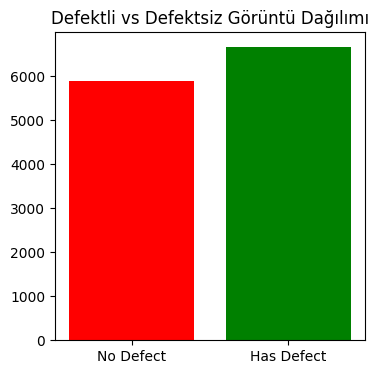

In [4]:
import os
import matplotlib.pyplot as plt

# Tất cả ảnh trong thư mục train
all_images = os.listdir("../input/severstal-steel-defect-detection/train_images")
all_images = [img for img in all_images if img.endswith(".jpg")]

# Ảnh có khuyết tật trong train.csv
defect_images = df["ImageId"].unique().tolist()

# Ảnh không có khuyết tật
no_defect_images = set(all_images) - set(defect_images)

print(f"Tổng số ảnh: {len(all_images)}")
print(f"Ảnh có khuyết tật: {len(defect_images)}")
print(f"Ảnh không khuyết tật: {len(no_defect_images)}")

# Biểu đồ cột
plt.figure(figsize=(4,4))
plt.bar(["Không lỗi", "Có lỗi"], [len(no_defect_images), len(defect_images)], color=["red", "green"])
plt.title("Phân bố ảnh có/không khuyết tật")
plt.show()


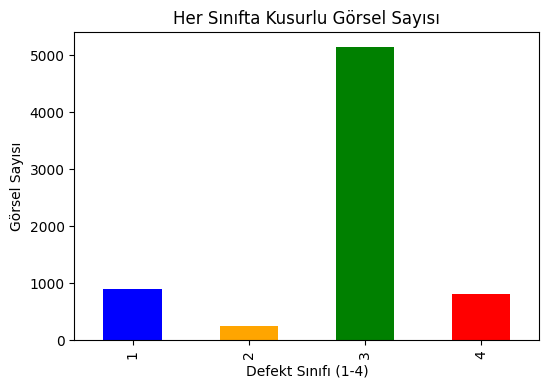

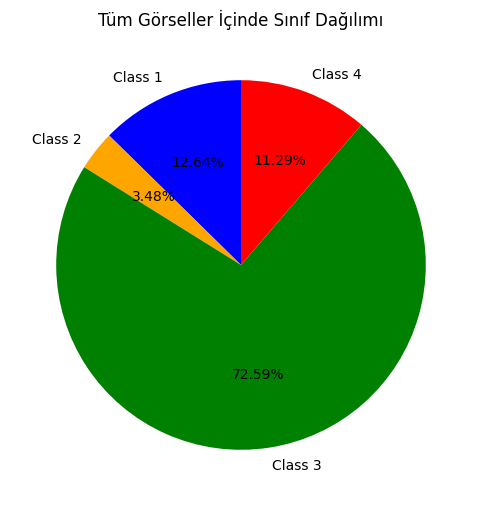

📊 Sınıf Bazında Kusurlu Görsel Sayıları:
ClassId
1     897
2     247
3    5150
4     801
Name: ImageId, dtype: int64

📊 Sınıf Bazında Oranlar (%):
ClassId
1    13.46
2     3.71
3    77.26
4    12.02
Name: ImageId, dtype: float64


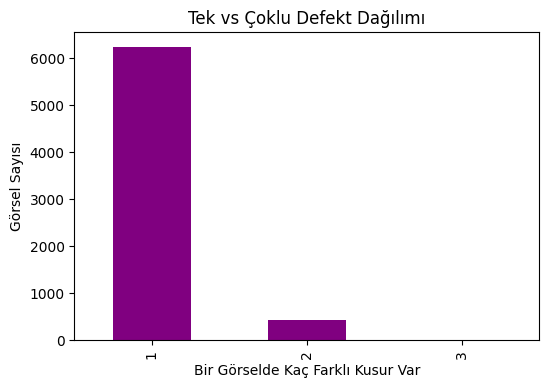

📊 Tek defektli görseller: 6239
📊 Çoklu defektli görseller: 427
         Kusurlu Görsel Sayısı  Tüm Görsellere Oranı (%)
ClassId                                                 
1                          897                     13.46
2                          247                      3.71
3                         5150                     77.26
4                          801                     12.02


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Tải train.csv
df = pd.read_csv("../input/severstal-steel-defect-detection/train.csv")

# Số ảnh có ít nhất một khuyết tật theo từng lớp
class_counts = df.loc[df["EncodedPixels"].notnull()] \
                 .groupby("ClassId")["ImageId"].nunique()

# Tổng số ảnh
total_images = df["ImageId"].nunique()

# Biểu đồ 1: Số ảnh có lỗi theo từng lớp
plt.figure(figsize=(6,4))
class_counts.plot(kind="bar", color=["blue","orange","green","red"])
plt.title("Số ảnh có khuyết tật theo lớp")
plt.ylabel("Số ảnh")
plt.xlabel("Lớp khuyết tật (1-4)")
plt.show()
# Tỷ lệ trên toàn bộ dataset
class_ratios = class_counts / total_images * 100

# Biểu đồ 2: Tròn
plt.figure(figsize=(6,6))
plt.pie(class_ratios, labels=[f"Lớp {c}" for c in class_counts.index],
        autopct="%.2f%%", startangle=90, colors=["blue","orange","green","red"])
plt.title("Tỷ lệ lớp trên toàn bộ ảnh")
plt.show()



print("📊 Số ảnh có khuyết tật theo lớp:")
print(class_counts)
print("\n📊 Tỷ lệ theo lớp (%):")
print(class_ratios.round(2))

# Số lớp khác nhau trên mỗi ảnh
defects_per_image = df.loc[df["EncodedPixels"].notnull()] \
                      .groupby("ImageId")["ClassId"].nunique()

# Histogram
plt.figure(figsize=(6,4))
defects_per_image.value_counts().sort_index().plot(kind="bar", color="purple")
plt.xlabel("Số loại khuyết tật trên một ảnh")
plt.ylabel("Số ảnh")
plt.title("Một lỗi vs nhiều lỗi trên cùng ảnh")
plt.show()

print("📊 Ảnh chỉ có một loại lỗi:", (defects_per_image==1).sum())
print("📊 Ảnh có nhiều loại lỗi:", (defects_per_image>1).sum())

summary = pd.DataFrame({
    "Số ảnh có lỗi": class_counts,
    "Tỷ lệ trên tổng ảnh (%)": class_ratios.round(2)
})
print(summary)


### 4. Hàm RLE và dựng mask

Các hàm giải mã / mã hóa **Run-Length Encoding (RLE)** từ `train.csv` trên Kaggle:

- **`rle_decode(mask_rle)`** → chuỗi RLE thành mask nhị phân (H×W).
- **`rle_encode(mask)`** → mask nhị phân thành RLE (dùng khi submission).
- **`build_masks(image_id, df)`** → gộp mask 4 lớp thành tensor `(H, W, C)`.

📌 Có thể trực quan: ảnh gốc, mask từng lớp, overlay màu —  
để **kiểm tra dữ liệu và mask khớp đúng**.


In [6]:
def rle_decode(mask_rle: str, shape=(CFG["HEIGHT"], CFG["WIDTH"])) -> np.ndarray:
    if not isinstance(mask_rle, str) or mask_rle.strip()=="":
        return np.zeros(shape, dtype=np.uint8)
    s = list(map(int, mask_rle.split()))
    starts, lengths = s[0::2], s[1::2]
    starts = np.asarray(starts) - 1
    ends   = starts + np.asarray(lengths)
    img = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape, order="F")

def rle_encode(mask: np.ndarray) -> str:
    pixels = mask.flatten(order="F")
    pads = np.pad(pixels, (1,1), constant_values=0)
    changes = np.where(pads[1:] != pads[:-1])[0] + 1
    starts, ends = changes[::2], changes[1::2]
    lengths = ends - starts
    if len(starts)==0:
        return ""
    return " ".join(f"{s} {l}" for s,l in zip(starts, lengths))

def build_masks(image_id: str, df: pd.DataFrame,
                shape=(CFG["HEIGHT"], CFG["WIDTH"]),
                num_classes=CFG["NUM_CLASSES"]) -> np.ndarray:
    m = np.zeros((shape[0], shape[1], num_classes), dtype=np.uint8)
    for c in range(1, num_classes+1):
        rles = df.loc[(df["ImageId"]==image_id) & (df["ClassId"]==c), "EncodedPixels"]
        if rles.notnull().any():
            for rle in rles:
                m[..., c-1] |= rle_decode(rle, shape)
    return m


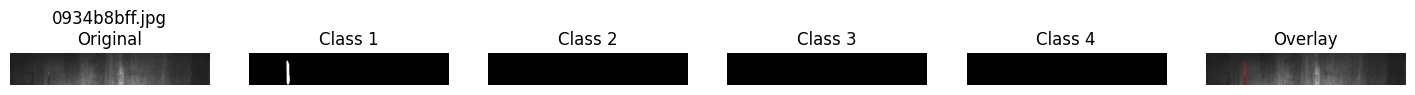

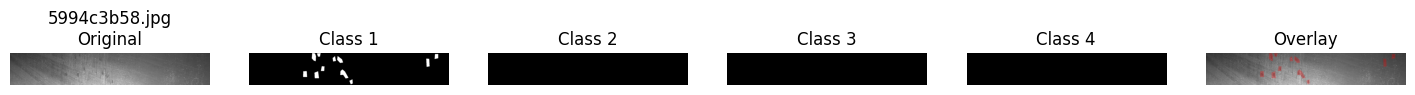

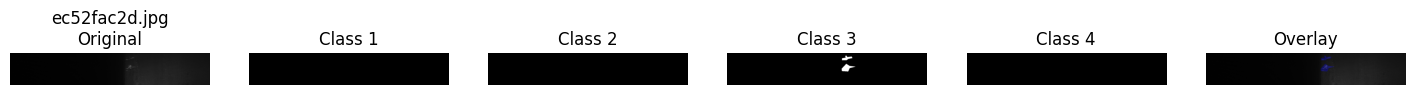

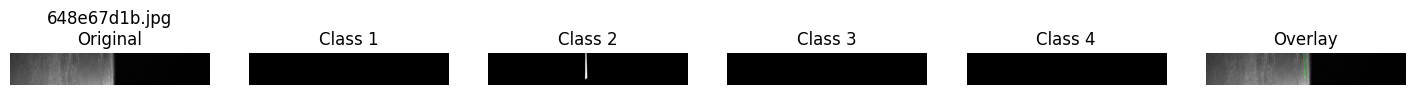

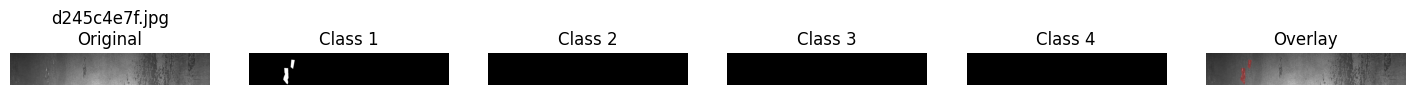

In [7]:
import cv2
import matplotlib.pyplot as plt

sample_images = df["ImageId"].drop_duplicates().sample(5, random_state=42).tolist()

for image_id in sample_images:
    img_path = TRAIN_DIR / image_id
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    masks = build_masks(image_id, df)

    plt.figure(figsize=(18,4))
    plt.subplot(1,6,1)
    plt.imshow(img)
    plt.title(f"{image_id}\nGốc")
    plt.axis("off")

    # Mask từng lớp
    for i in range(4):
        plt.subplot(1,6,i+2)
        plt.imshow(masks[..., i], cmap="gray")
        plt.title(f"Lớp {i+1}")
        plt.axis("off")

    # Chồng màu (overlay)
    overlay = img.copy()
    colors = [(255,0,0), (0,255,0), (0,0,255), (255,255,0)]  # Đỏ, Xanh lá, Xanh dương, Vàng
    for i in range(4):
        mask = masks[..., i].astype(bool)
        overlay[mask] = (0.7*overlay[mask] + 0.3*np.array(colors[i])).astype(np.uint8)

    plt.subplot(1,6,6)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()


### 5. Transform (tăng cường dữ liệu)

Dùng `Albumentations` để giảm **overfitting** và tăng độ bền mô hình.

- **Transform train (`get_train_transforms`)**  
  - `HorizontalFlip`: lật ngang.  
  - `Affine`: scale, dịch, xoay nhẹ.  
  - `GaussianBlur`: làm mờ nhẹ.  
  - `RandomBrightnessContrast`: đổi độ sáng/tương phản.  
  - `Resize`: về kích thước cố định.  
  - `Normalize + ToTensorV2`: chuẩn hóa và tensor PyTorch.

- **Transform validation (`get_valid_transforms`)**  
  - Chỉ `Resize` và `Normalize` (không augmentation).

📌 Hàm `visualize_random_aug`:  
- Lấy một ảnh + mask, augment và hiển thị overlay —  
- Kiểm tra augmentation **đúng và hợp lý** (mask vẫn khớp ảnh).

*Ghi chú: mô tả bootcamp có nhắc `CropNonEmptyMaskIfExists` nhưng code dưới không dùng bước đó.*


In [8]:
def get_train_transforms(H=CFG["HEIGHT"], W=CFG["WIDTH"]):
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Affine(scale=(0.9,1.1), translate_percent=(0.02,0.02), rotate=(-5,5), p=0.5),
        A.GaussianBlur(blur_limit=(3, 7), p=0.2),
        A.RandomBrightnessContrast(p=0.4),
        A.Resize(H, W, interpolation=1),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ], is_check_shapes=False)

def get_valid_transforms(H=CFG["HEIGHT"], W=CFG["WIDTH"]):
    return A.Compose([
        A.Resize(H, W, interpolation=1),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ])


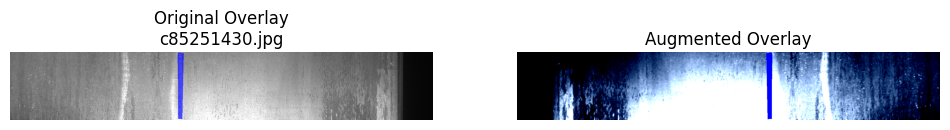

In [9]:
import random

def visualize_random_aug(df, train_dir=TRAIN_DIR, transforms=get_train_transforms()):
    # Chọn ngẫu nhiên một ảnh
    image_id = random.choice(df["ImageId"].unique().tolist())
    img_path = train_dir / image_id
    
    # Đọc ảnh
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Tạo mask
    masks = build_masks(image_id, df)   # (H,W,4)
    
    # Augment bằng Albumentations
    aug = transforms(image=img, masks=[masks[...,i] for i in range(4)])
    aug_img = aug["image"].permute(1,2,0).cpu().numpy()   # CHW -> HWC
    aug_masks = np.stack(aug["masks"], axis=-1)           # ghép lại các kênh
    
    # Hàm overlay
    def overlay_image(base, masks, alpha=0.3):
        colors = [(255,0,0), (0,255,0), (0,0,255), (255,255,0)]
        overlay = base.copy()
        for i in range(masks.shape[-1]):
            mask = masks[..., i].astype(bool)
            overlay[mask] = (alpha*overlay[mask] + (1-alpha)*np.array(colors[i])).astype(np.uint8)
        return overlay
    
    orig_overlay = overlay_image(img, masks)
    aug_overlay  = overlay_image(aug_img, aug_masks)
    
    # Vẽ
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.imshow(orig_overlay)
    plt.title(f"Overlay gốc\n{image_id}")
    plt.axis("off")
    
    plt.subplot(1,2,2)
    plt.imshow(aug_overlay)
    plt.title("Overlay sau augment")
    plt.axis("off")
    
    plt.show()

# Mỗi lần chạy hiển thị một mẫu ngẫu nhiên
visualize_random_aug(df)


### 6. Lớp Dataset và DataLoader

**PyTorch `Dataset`** cho huấn luyện:

- **`SteelDefectDataset`**
  - Đọc ảnh **grayscale**, nhân **3 kênh** (tương thích backbone ImageNet).  
  - Mask từ `build_masks` (RLE → 4 kênh).  
  - `Albumentations` áp dụng đồng thời ảnh và mask.
  - Trả về `(image, mask, meta)`  
    - `image`: `(3,H,W)`  
    - `mask`: `(4,H,W)`  
    - `meta`: id ảnh.

- **`collate_fn`**
  - Gộp batch thành tensor.

- **DataLoader**
  - Chia train/val bằng `train_test_split`.  
  - `train_loader`: shuffle=True, có augmentation.  
  - `valid_loader`: shuffle=False, chỉ resize/normalize.

📌 Cuối cell: lấy một batch, in `images.shape`, `masks.shape`, `meta` để kiểm tra pipeline.


In [10]:
class SteelDefectDataset(Dataset):
    def __init__(self, image_ids, image_dir: Path, df: pd.DataFrame, transforms=None, load_rgb=True):
        self.image_ids = list(image_ids)
        self.image_dir = image_dir
        self.df = df
        self.transforms = transforms
        self.load_rgb = load_rgb

    def __len__(self):
        return len(self.image_ids)

    def _read_image(self, image_id):
        img = cv2.imread(str(self.image_dir / image_id), cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(image_id)
        if self.load_rgb:
            img = np.repeat(img[..., None], 3, axis=2)  # (H,W,3)
        return img

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img = self._read_image(image_id)
        mask = build_masks(image_id, self.df)  # (H,W,C)

        if self.transforms:
            out = self.transforms(image=img, mask=mask)
            img, mask = out["image"], out["mask"].permute(2,0,1)  # -> (C,H,W)
        else:
            img = torch.from_numpy(img.transpose(2,0,1)).float()
            mask = torch.from_numpy(mask.transpose(2,0,1)).float()

        meta = {"image_id": image_id}
        return img, mask, meta


# --- Hàm collate ---
def collate_fn(batch):
    images, masks, metas = zip(*batch)
    images = torch.stack(images)
    masks = torch.stack(masks)
    return images, masks, metas


# --- Dataset & DataLoader (kiểm tra nhanh) ---
train_ids, valid_ids = train_test_split(
    df["ImageId"].unique(),
    test_size=CFG["VAL_SPLIT"],
    random_state=SEED
)

train_ds = SteelDefectDataset(train_ids, TRAIN_DIR, df, transforms=get_train_transforms())
valid_ds = SteelDefectDataset(valid_ids, TRAIN_DIR, df, transforms=get_valid_transforms())

train_loader = DataLoader(train_ds, batch_size=CFG["BATCH_SIZE"],
                          shuffle=True, num_workers=CFG["NUM_WORKERS"],
                          collate_fn=collate_fn)

valid_loader = DataLoader(valid_ds, batch_size=CFG["BATCH_SIZE"],
                          shuffle=False, num_workers=CFG["NUM_WORKERS"],
                          collate_fn=collate_fn)


# --- Kiểm tra một batch ---
batch = next(iter(train_loader))
images, masks, metas = batch

print("Shape ảnh:", images.shape)   # (B, 3, H, W)
print("Shape mask:", masks.shape)     # (B, 4, H, W)
print("Ví dụ meta:", metas[0])


Images shape: torch.Size([8, 3, 256, 1600])
Masks shape: torch.Size([8, 4, 256, 1600])
Meta örnek: {'image_id': '843f0ae15.jpg'}


### 7. Chia Train / Validation

Chia dataset **theo từng ảnh**:

- **Stratify**:  
  - Tạo nhãn `any_defect`: ảnh có ít nhất một lỗi = 1, không lỗi = 0.  
  - Giữ **tỷ lệ có/không lỗi** giữa train và val.

- **DataLoader**:  
  - `train_loader`: có augmentation, shuffle=True.  
  - `val_loader`: chỉ resize + normalize, shuffle=False.

📌 Giúp tập validation **đại diện hơn** khi số ảnh có lỗi ít.


In [11]:
all_ids = df["ImageId"].unique()
any_defect = df.groupby("ImageId")["EncodedPixels"].apply(lambda s: s.notnull().any()).astype(int)
train_ids, val_ids = train_test_split(all_ids, test_size=CFG["VAL_SPLIT"],
                                      random_state=SEED, stratify=any_defect.loc[all_ids])

train_ds = SteelDefectDataset(train_ids, TRAIN_DIR, df, transforms=get_train_transforms())
val_ds   = SteelDefectDataset(val_ids,   TRAIN_DIR, df, transforms=get_valid_transforms())

train_loader = DataLoader(train_ds, batch_size=CFG["BATCH_SIZE"], shuffle=True,
                          num_workers=CFG["NUM_WORKERS"], pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["BATCH_SIZE"], shuffle=False,
                          num_workers=CFG["NUM_WORKERS"], pin_memory=True)


### 8. Mô hình: Attention U-Net + Encoder ResNet18

**Attention U-Net** với **backbone ResNet18** cho phân đoạn khuyết tật thép.

#### 🔹 Encoder (ResNet18)
- Dựa trên `torchvision.models.resnet18`.
- Dùng **conv1, bn1, relu, layer1–4** làm encoder.
- Bỏ `avgpool` và `fc`.
- Tận dụng **trọng số pretrained ImageNet**.

#### 🔹 Decoder (Attention + skip)
- Upsample bilinear từng tầng về kích thước skip tương ứng.
- **`AttentionGate`**: lọc skip connection theo tín hiệu decoder.
- **Concat** skip đã gating + feature decoder, rồi **`ConvBlock`** tinh chỉnh.

#### 🔹 Đầu ra
- `Conv2d(64, num_classes, 1)`.
- `F.interpolate` về đúng `(H,W)` đầu vào nếu cần.

---

✅ Kết hợp **ResNet18 pretrained**, **cơ chế attention** và **skip U-Net**.


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import ResNet18_Weights


class AttentionGate(nn.Module):
    """Cổng attention trên skip connection (g: decoder, x: encoder)."""

    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, bias=True),
            nn.BatchNorm2d(F_int),
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, bias=True),
            nn.BatchNorm2d(F_int),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        psi = self.relu(self.W_g(g) + self.W_x(x))
        psi = self.psi(psi)
        return x * psi


class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    """Upsample 2x (bilinear) + conv giảm kênh."""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, size):
        x = F.interpolate(x, size=size, mode="bilinear", align_corners=False)
        return self.conv(x)


class AttUNetResNet18(nn.Module):
    """ResNet18 encoder + Attention U-Net decoder."""

    def __init__(self, num_classes=CFG["NUM_CLASSES"], pretrained=True, dropout=0.0):
        super().__init__()
        base = models.resnet18(
            weights=ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        )
        del base.fc, base.avgpool

        self.enc1 = nn.Sequential(base.conv1, base.bn1, base.relu)
        self.enc2 = nn.Sequential(base.maxpool, base.layer1)
        self.enc3 = base.layer2
        self.enc4 = base.layer3
        self.enc5 = base.layer4

        # e5:512 -> 256 | skip e4:256
        self.up4 = UpBlock(512, 256)
        self.att4 = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.dec4 = ConvBlock(512, 256)

        # -> 128 | skip e3:128
        self.up3 = UpBlock(256, 128)
        self.att3 = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.dec3 = ConvBlock(256, 128)

        # -> 64 | skip e2:64
        self.up2 = UpBlock(128, 64)
        self.att2 = AttentionGate(F_g=64, F_l=64, F_int=32)
        self.dec2 = ConvBlock(128, 64)

        # -> 64 | skip e1:64
        self.up1 = UpBlock(64, 64)
        self.att1 = AttentionGate(F_g=64, F_l=64, F_int=32)
        self.dec1 = ConvBlock(128, 64)

        self.final = nn.Conv2d(64, num_classes, kernel_size=1)
        self.drop = nn.Dropout2d(p=dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)

        d4 = self.up4(e5, e4.shape[2:])
        d4 = self.dec4(torch.cat([self.att4(d4, e4), d4], dim=1))
        d4 = self.drop(d4)

        d3 = self.up3(d4, e3.shape[2:])
        d3 = self.dec3(torch.cat([self.att3(d3, e3), d3], dim=1))
        d3 = self.drop(d3)

        d2 = self.up2(d3, e2.shape[2:])
        d2 = self.dec2(torch.cat([self.att2(d2, e2), d2], dim=1))
        d2 = self.drop(d2)

        d1 = self.up1(d2, e1.shape[2:])
        d1 = self.dec1(torch.cat([self.att1(d1, e1), d1], dim=1))

        out = self.final(d1)
        if out.shape[2:] != x.shape[2:]:
            out = F.interpolate(out, size=x.shape[2:], mode="bilinear", align_corners=False)
        return out


### 9) Hàm loss và metric

Xử lý **mất cân bằng lớp** và cải thiện chất lượng mask bằng **Focal Loss + Dice Loss**.

- **DiceLoss**
  - Metric phổ biến cho segmentation.
  - Nhấn mạnh vùng mask nhỏ.
  - `smooth` tránh chia cho 0.

- **WeightedFocalDiceLoss**
  - Focal: tập trung mẫu khó.
  - Dice: căn chỉnh hình học mask.
  - `class_weights`: tăng trọng số lớp hiếm.
  - `gamma`: tham số focal.
  - `lam_f`, `lam_d`: trọng số focal vs dice.
  - `return_details=True`: tách loss focal và dice.

- **dice_coefficient**
  - Dice trung bình trên batch (theo dõi train/val).

- **dice_per_class**
  - Dice từng lớp — biết lớp nào yếu.


In [13]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0): super().__init__(); self.smooth=smooth
    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        p = probs.view(probs.size(0), probs.size(1), -1)
        t = targets.view(targets.size(0), targets.size(1), -1)
        inter = (p*t).sum(2); den = p.sum(2)+t.sum(2)
        dice = (2*inter + self.smooth) / (den + self.smooth)
        return 1.0 - dice.mean()

class WeightedFocalDiceLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0, lam_f=0.7, lam_d=0.3):
        super().__init__()
        self.w = class_weights
        self.g = gamma
        self.lf = lam_f
        self.ld = lam_d
        self.dice = DiceLoss()

    def forward(self, logits, targets, return_details=False):
        probs = torch.sigmoid(logits)
        eps = 1e-8

        # BCE
        bce = -(targets * torch.log(probs + eps) +
                (1 - targets) * torch.log(1 - probs + eps))

        # Điều chế focal
        pt = torch.where(targets == 1, probs, 1 - probs)
        fw = (1 - pt) ** self.g

        if self.w is not None:
            fw = fw * logits.new_tensor(self.w).view(1, -1, 1, 1)

        focal = (fw * bce).mean()
        dice = self.dice(logits, targets)

        loss = self.lf * focal + self.ld * dice

        if return_details:
            return loss, {"focal": focal.item(), "dice": dice.item()}
        return loss

@torch.no_grad()
def dice_coefficient(logits, targets, thr=CFG["THRESHOLD"], eps=1e-6):
    probs = torch.sigmoid(logits); preds = (probs>thr).float()
    inter = (preds*targets).sum((2,3)); den = preds.sum((2,3))+targets.sum((2,3))
    dice = (2*inter+eps)/(den+eps)
    return dice.mean()

@torch.no_grad()
def dice_per_class(logits, targets, thr=CFG["THRESHOLD"], eps=1e-6):
    probs = torch.sigmoid(logits); preds = (probs>thr).float()
    inter = (preds*targets).sum((0,2,3)); den = preds.sum((0,2,3))+targets.sum((0,2,3))
    return ((2*inter+eps)/(den+eps)).cpu().tolist()


### 10) Vòng lặp huấn luyện (Training Engine)

Ba phần chính:

---

#### 🔹 1. Hàm theo epoch
- **`train_one_epoch`**:  
  - `train` mode, forward → loss → backward → step.  
  - Trả về **loss** và **Dice** trung bình.

- **`validate_one_epoch`**:  
  - `eval` mode, `@torch.no_grad()`.  
  - Loss và Dice trên tập validation.

Định dạng batch: `(imgs, masks, meta)`.

---

#### 🔹 2. EarlyStopping
- Chống overfitting, `mode="max"` theo **Dice**.  
- Hết `patience` epoch không cải thiện thì dừng.

---

#### 🔹 3. `fit()`
- Mỗi epoch: train + validate.  
- **ReduceLROnPlateau** theo val Dice.  
- Ghi `history`, lưu `best_model.pth` khi Dice tốt nhất.  
- Early stopping khi cần.

---

#### 🔹 4. Kiểm tra tương thích
- Dataset → `(imgs, masks, meta)` ✓  
- Model → logits `(B, NUM_CLASSES, H, W)` ✓  
- Loss / metric / scheduler ✓  

---

✅ Quy trình train có theo dõi metric, giảm LR và dừng sớm tự động.


In [14]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    run_loss, run_dice, n = 0.0, 0.0, 0
    for imgs, masks, _ in tqdm(loader, desc="Train", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, masks)
        loss.backward()
        optimizer.step()
        bs = imgs.size(0); n += bs
        run_loss += loss.item() * bs
        run_dice += dice_coefficient(out, masks).item() * bs
    return {"loss": run_loss/n, "dice": run_dice/n}


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    run_loss, run_dice, n = 0.0, 0.0, 0
    for imgs, masks, _ in tqdm(loader, desc="Valid", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        out = model(imgs)
        loss = criterion(out, masks)
        bs = imgs.size(0); n += bs
        run_loss += loss.item() * bs
        run_dice += dice_coefficient(out, masks).item() * bs
    return {"loss": run_loss/n, "dice": run_dice/n}


class EarlyStopping:
    def __init__(self, patience=5, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best = None
        self.count = 0
        self.stop = False

    def __call__(self, score):
        if self.best is None:
            self.best = score; self.count = 0
        else:
            improve = (score > self.best) if self.mode=="max" else (score < self.best)
            if improve:
                self.best = score; self.count = 0
            else:
                self.count += 1
                if self.count >= self.patience:
                    self.stop = True


def fit(model, train_loader, val_loader, optimizer, scheduler, criterion, device,
        num_epochs=CFG["EPOCHS"], early_stopping_patience=5, save_path="best_model.pth"):
    early_stopping = EarlyStopping(patience=early_stopping_patience, mode="max")
    best_dice = -1.0

    history = {"train": [], "valid": []}

    for epoch in range(1, num_epochs+1):
        print(f"\nEpoch {epoch}/{num_epochs}")

        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics   = validate_one_epoch(model, val_loader, criterion, device)

        # Thêm Dice theo từng lớp
        all_val_dice = []
        for imgs, masks, _ in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            out = model(imgs)
            all_val_dice.append(dice_per_class(out, masks))
        val_metrics["per_class_dice"] = np.mean(all_val_dice, axis=0).tolist()

        scheduler.step(val_metrics["dice"])

        print(f"Train Loss: {train_metrics['loss']:.4f}, Dice: {train_metrics['dice']:.4f}")
        print(f"Valid Loss: {val_metrics['loss']:.4f}, Dice: {val_metrics['dice']:.4f}")

        history["train"].append({**train_metrics, "lr": optimizer.param_groups[0]["lr"]})
        history["valid"].append(val_metrics)

        if val_metrics["dice"] > best_dice:
            best_dice = val_metrics["dice"]
            torch.save(model.state_dict(), save_path)
            print(f"✅ Đã lưu model tốt nhất ở epoch {epoch} (dice={best_dice:.4f})")

        early_stopping(val_metrics["dice"])
        if early_stopping.stop:
            print("⏹️ Early stopping được kích hoạt.")
            break

    print(f"Huấn luyện xong. Dice tốt nhất = {best_dice:.4f}")
    return history


### 📊 Trực quan hóa biểu đồ huấn luyện

- `plot_history` vẽ từ `history`:
  - **Dice** (train & valid)  
  - **Loss** (train & valid)  
  - **Learning rate**  
  - (tùy chọn) Dice theo lớp nếu có trong `history`.
- Lưu PNG và hiển thị trong notebook.


In [15]:
def plot_history(history, out_dir=WORK_DIR, show=True):
    tr_d = [e["dice"] for e in history["train"]]
    va_d = [e["dice"] for e in history["valid"]]
    tr_l = [e["loss"] for e in history["train"]]
    va_l = [e["loss"] for e in history["valid"]]
    lr   = [e["lr"] for e in history["train"]]

    # Dice
    plt.figure()
    plt.plot(tr_d, label="Train")
    plt.plot(va_d, label="Valid")
    plt.title("Dice Score")
    plt.legend()
    plt.savefig(out_dir / "dice_curve.png")
    if show: plt.show()
    plt.close()

    # Loss
    plt.figure()
    plt.plot(tr_l, label="Train")
    plt.plot(va_l, label="Valid")
    plt.title("Loss")
    plt.legend()
    plt.savefig(out_dir / "loss_curve.png")
    if show: plt.show()
    plt.close()

    # Learning Rate
    plt.figure()
    plt.plot(lr, label="LR")
    plt.title("Learning Rate")
    plt.legend()
    plt.savefig(out_dir / "lr_curve.png")
    if show: plt.show()
    plt.close()

import matplotlib.pyplot as plt
import numpy as np
import torch

# 1) Vẽ biểu đồ quá trình train
def plot_training_curves(history, out_dir=WORK_DIR):
    tr_d = [e["dice"] for e in history["train"]]
    va_d = [e["dice"] for e in history["valid"]]
    tr_l = [e["loss"] for e in history["train"]]
    va_l = [e["loss"] for e in history["valid"]]
    lr   = [e["lr"] for e in history["train"]]

    # Dice
    plt.figure(figsize=(6,4))
    plt.plot(tr_d, label="Train Dice")
    plt.plot(va_d, label="Valid Dice")
    plt.title("Dice Score")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.legend()
    plt.grid(True)
    plt.savefig(out_dir/"dice_curve.png")
    plt.show()

    # Loss
    plt.figure(figsize=(6,4))
    plt.plot(tr_l, label="Train Loss")
    plt.plot(va_l, label="Valid Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(out_dir/"loss_curve.png")
    plt.show()

    # LR
    plt.figure(figsize=(6,4))
    plt.plot(lr, label="LR")
    plt.title("Learning Rate")
    plt.xlabel("Epoch")
    plt.ylabel("LR")
    plt.grid(True)
    plt.savefig(out_dir/"lr_curve.png")
    plt.show()


# 2) Dice theo từng lớp
@torch.no_grad()
def plot_per_class_dice(model, loader, device, class_names=None):
    model.eval()
    dices = []
    for imgs, masks, _ in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        dices.append(dice_per_class(logits, masks))

    dices = np.array(dices).mean(0)
    if class_names is None:
        class_names = [f"Lớp {i+1}" for i in range(len(dices))]

    plt.figure(figsize=(6,4))
    plt.bar(class_names, dices, color=["blue","orange","green","red"])
    plt.title("Dice theo từng lớp")
    plt.ylabel("Dice")
    plt.ylim(0,1)
    plt.grid(True, axis="y")
    plt.show()


# 3) Trực quan hóa dự đoán mẫu
@torch.no_grad()
def visualize_predictions(model, dataset, device, k=3, thr=CFG["THRESHOLD"]):
    model.eval()
    idxs = np.random.choice(len(dataset), size=min(k,len(dataset)), replace=False)
    for i in idxs:
        img, mask, meta = dataset[i]
        x = img.unsqueeze(0).to(device)
        pred = torch.sigmoid(model(x))[0].cpu().numpy().transpose(1,2,0)
        pred_bin = (pred > thr).astype(np.uint8)

        img_np  = img.permute(1,2,0).numpy()
        mask_np = mask.permute(1,2,0).numpy()

        fig, axs = plt.subplots(1,3,figsize=(15,5))
        axs[0].imshow((img_np-img_np.min())/(img_np.max()-img_np.min()+1e-8))
        axs[0].set_title(meta["image_id"]); axs[0].axis("off")

        axs[1].imshow(mask_np.max(-1), cmap="gray")
        axs[1].set_title("Ground Truth"); axs[1].axis("off")

        axs[2].imshow(pred_bin.max(-1), cmap="gray")
        axs[2].set_title("Dự đoán"); axs[2].axis("off")
        plt.show()


### 11) Giai đoạn huấn luyện

---

#### 🔹 1. Định nghĩa model
- **`AttUNetResNet18`** với tham số từ **CFG** (`num_classes`, `pretrained`).
- Đưa lên `device` nếu có GPU.

---

#### 🔹 2. Loss
- **`WeightedFocalDiceLoss`**: Focal + Dice.
- Class weights `[0.12, 0.03, 0.72, 0.11]` cho mất cân bằng.

---

#### 🔹 3. Tối ưu
- **Adam** (LR, weight decay từ CFG).
- **ReduceLROnPlateau**: giảm LR khi val Dice không cải thiện (`patience=3` trong code cell).

---

#### 🔹 4. Phần cứng
- In phiên bản PyTorch, CUDA, tên GPU.

---

#### 🔹 5. Huấn luyện
- Gọi **`fit()`**, lưu `history`.
- `best_model.pth` / `last_model.pth`.

---

#### 🔹 6. Biểu đồ
- `plot_history()` theo dõi loss, dice, lr.

---

✅ Sau bước này có checkpoint cho submission và inference.


In [ ]:
# Định nghĩa model, loss, optimizer, scheduler
model = AttUNetResNet18(num_classes=CFG["NUM_CLASSES"],
                     pretrained=CFG["PRETRAINED"]).to(device)

criterion = WeightedFocalDiceLoss(class_weights=[0.12,0.03,0.72,0.11])
optimizer = Adam(model.parameters(), lr=CFG["LR"], weight_decay=CFG["WEIGHT_DECAY"])
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("Không có GPU, đang chạy trên CPU.")


# Bắt đầu train và lưu history
history = fit(model, train_loader, val_loader, optimizer, scheduler, criterion, device,
              num_epochs=CFG["EPOCHS"], early_stopping_patience=10, save_path="best_model.pth")

# Lưu weights epoch cuối
torch.save(model.state_dict(), "last_model.pth")

# --- Phân tích sau train ---

# 1) Biểu đồ loss, dice, lr
plot_history(history, show=True)        # lưu file và hiển thị
plot_training_curves(history)           # phiên bản có lưới

# 2) Dice theo lớp (validation)
plot_per_class_dice(model, val_loader, device)

# 3) Ví dụ GT vs dự đoán
visualize_predictions(model, val_ds, device, k=3)

# Đường dẫn model tốt nhất
best_path = "best_model.pth"


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s] 


PyTorch version: 2.6.0+cu124
CUDA available: True
GPU name: Tesla T4

Epoch 1/200


Train:  49%|████▊     | 325/667 [01:27<01:31,  3.74it/s]

### 🧪 Tập test và chuẩn bị inference

Sau train, chuẩn bị **tập test** để suy luận:

- **`SteelDefectTestDataset`**:  
  - Đọc grayscale, nhân 3 kênh RGB.  
  - Trả về `(tensor, image_id)` (không có mask).

- **Transform test**:  
  - `Resize`, normalize ImageNet, `ToTensorV2`.

- **DataLoader**:  
  - `shuffle=False` giữ thứ tự file khi submission.  
  - `pin_memory=True` tăng tốc GPU.

- **Nạp model**:  
  - `AttUNetResNet18` + `best_model.pth`, `.eval()`.

Model sẵn sàng **dự đoán trên test set**.


In [ ]:
# class SteelDefectTestDataset(Dataset):
#     def __init__(self, image_ids, image_dir: Path, transforms=None, load_rgb=True):
#         self.image_ids = list(image_ids)
#         self.image_dir = image_dir
#         self.transforms = transforms
#         self.load_rgb = load_rgb

#     def __len__(self): return len(self.image_ids)

#     def _read_image(self, image_id):
#         img = cv2.imread(str(self.image_dir / image_id), cv2.IMREAD_GRAYSCALE)
#         if img is None: raise FileNotFoundError(image_id)
#         if self.load_rgb: img = np.repeat(img[...,None], 3, axis=2)
#         return img

#     def __getitem__(self, idx):
#         image_id = self.image_ids[idx]
#         img = self._read_image(image_id)
#         if self.transforms:
#             out = self.transforms(image=img)
#             img = out["image"]
#         else:
#             img = torch.from_numpy(img.transpose(2,0,1)).float()
#         return img, image_id


# # Transform test (resize + normalize)
# test_transforms = A.Compose([
#     A.Resize(CFG["HEIGHT"], CFG["WIDTH"], interpolation=1),
#     A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
#     ToTensorV2(),
# ])

# # Dataset & loader test
# test_ids = os.listdir(TEST_DIR)
# test_ids = [img for img in test_ids if img.endswith(".jpg")]

# test_ds = SteelDefectTestDataset(test_ids, TEST_DIR, transforms=test_transforms)
# test_loader = DataLoader(test_ds, batch_size=CFG["BATCH_SIZE"],
#                          shuffle=False, num_workers=CFG["NUM_WORKERS"], pin_memory=True)


# # Nạp model
# model = AttUNetResNet18(num_classes=CFG["NUM_CLASSES"],
#                      pretrained=False)
# model.load_state_dict(torch.load("best_model.pth", map_location=device))
# model.to(device).eval()


### 📤 Chuẩn bị file submission

- Model dự đoán trên test (`eval`).
- `sigmoid` → ngưỡng → mask nhị phân.
- Mã hóa **RLE** từng lớp.
- DataFrame cột `ImageId, ClassId, EncodedPixels`.
- Mask rỗng → `NaN`, lưu `submission.csv`.


In [ ]:
# sub = []

# with torch.no_grad():
#     for imgs, image_ids in tqdm(test_loader, desc="Inference"):
#         imgs = imgs.to(device)
#         logits = model(imgs)
#         probs = torch.sigmoid(logits)
#         preds = (probs > CFG["THRESHOLD"]).float().cpu().numpy()

#         # (B, C, H, W) -> RLE cho từng ảnh, từng lớp
#         for i in range(preds.shape[0]):
#             image_id = image_ids[i]
#             for c in range(CFG["NUM_CLASSES"]):
#                 mask = preds[i, c]
#                 mask = (mask > 0.5).astype(np.uint8)
#                 rle = rle_encode(mask)
#                 sub.append([image_id, c+1, rle])

# # Tạo DataFrame
# sub_df = pd.DataFrame(sub, columns=["ImageId","ClassId","EncodedPixels"])

# # Định dạng Kaggle: mask rỗng phải là NaN
# sub_df.loc[sub_df["EncodedPixels"]=="", "EncodedPixels"] = np.nan

# # Lưu file
# sub_df.to_csv("submission.csv", index=False)
# print("✅ Đã tạo submission.csv:", sub_df.shape)


### 13) Đánh giá định tính (code)

Sau train, metric số chưa đủ — cần xem trực quan vài ảnh:

* Ảnh đầu vào
* Mask ground truth (GT)
* Mask dự đoán

Đặt cạnh nhau để thấy lớp nào segment đúng/sai.


In [ ]:
# @torch.no_grad()
# def visualize_samples(model, dataset, k=3, thr=CFG["THRESHOLD"]):
#     model.eval()
#     idxs = np.random.choice(len(dataset), size=min(k, len(dataset)), replace=False)
#     for i in idxs:
#         img, mask, meta = dataset[i]   # Dataset __getitem__ -> (image, mask, meta)
#         x = img.unsqueeze(0).to(device)
#         pred = torch.sigmoid(model(x))[0].cpu().numpy().transpose(1,2,0)
#         pred_bin = (pred > thr).astype(np.uint8)

#         img_np  = img.permute(1,2,0).numpy()
#         mask_np = mask.permute(1,2,0).numpy()

#         fig, axs = plt.subplots(1, 3, figsize=(15, 5))
#         axs[0].imshow((img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8))
#         axs[0].set_title(meta["image_id"]); axs[0].axis("off")
#         axs[1].imshow(mask_np.max(-1), cmap="gray"); axs[1].set_title("GT (bất kỳ lớp)"); axs[1].axis("off")
#         axs[2].imshow(pred_bin.max(-1), cmap="gray"); axs[2].set_title("Dự đoán (bất kỳ lớp)"); axs[2].axis("off")
#         plt.show()

# # Nạp lại model tốt nhất đã lưu
# model.load_state_dict(torch.load(best_path, map_location=device))
# visualize_samples(model, val_ds, k=3)


# Stage 2

In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import torch
from tqdm import tqdm

CLS_CROP_SIZE = (384, 384)  # (H, W)
CLS_OUT_DIR = WORK_DIR / "cls_stage2"
CLS_CROP_DIR = CLS_OUT_DIR / "crops"
CLS_OUT_DIR.mkdir(parents=True, exist_ok=True)
CLS_CROP_DIR.mkdir(parents=True, exist_ok=True)

@torch.no_grad()
def predict_masks_for_batch(model, imgs, thr=0.5):
    """Return binary masks [B,C,H,W] on CPU (uint8)."""
    logits = model(imgs)
    probs = torch.sigmoid(logits)
    masks = (probs > thr).to(torch.uint8)
    return masks.cpu()

def _find_bboxes_from_binary_mask(mask2d, min_area=50):
    """mask2d: uint8 {0,1}.
    return list of (x1,y1,x2,y2) in pixel coords.
    """
    m = (mask2d * 255).astype(np.uint8)
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bboxes = []
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        if w * h < min_area:
            continue
        bboxes.append((x, y, x + w, y + h))
    return bboxes

def _clip_bbox(x1, y1, x2, y2, W, H):
    x1 = max(0, min(W - 1, x1))
    y1 = max(0, min(H - 1, y1))
    x2 = max(1, min(W, x2))
    y2 = max(1, min(H, y2))
    return x1, y1, x2, y2

def build_stage2_crops_from_predictions(
    model,
    test_loader,
    test_image_dir: Path,
    out_csv_path: Path,
    thr=0.5,
    min_component_area=80,
    label_min_pixels=30,
    bbox_margin=12,
    max_crops_per_image=12,
):
    """Tạo crop dataset + pseudo multi-label từ mask dự đoán.

    Ghi file CSV gồm:
      crop_path, image_id, x1,y1,x2,y2, y1..y4
    """
    model.eval()
    rows = []

    for imgs, image_ids in tqdm(test_loader, desc="Stage2 crops", leave=False):
        imgs = imgs.to(device)
        masks_b = predict_masks_for_batch(model, imgs, thr=thr)  # [B,C,H,W] uint8 cpu

        for bi, image_id in enumerate(image_ids):
            # đọc ảnh gốc (grayscale -> 3ch) để crop
            img_path = test_image_dir / image_id
            img0 = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img0 is None:
                continue
            img0 = np.repeat(img0[..., None], 3, axis=2)  # HxWx3

            # resize ảnh gốc về đúng size đang dùng trong segmentation (để bbox khớp mask)
            Hm, Wm = masks_b.shape[-2], masks_b.shape[-1]
            if img0.shape[0] != Hm or img0.shape[1] != Wm:
                img0 = cv2.resize(img0, (Wm, Hm), interpolation=cv2.INTER_LINEAR)

            # gom bbox từ mọi class
            bboxes = []
            for c in range(masks_b.shape[1]):
                m2d = masks_b[bi, c].numpy()
                bboxes += _find_bboxes_from_binary_mask(m2d, min_area=min_component_area)

            # nếu không có bbox nào: bỏ qua ảnh này
            if len(bboxes) == 0:
                continue

            # sort bbox theo diện tích giảm dần, giới hạn số crop/ảnh
            bboxes = sorted(bboxes, key=lambda b: (b[2]-b[0])*(b[3]-b[1]), reverse=True)[:max_crops_per_image]

            H, W = img0.shape[:2]

            for k, (x1, y1, x2, y2) in enumerate(bboxes):
                # nới bbox
                x1 -= bbox_margin; y1 -= bbox_margin
                x2 += bbox_margin; y2 += bbox_margin
                x1, y1, x2, y2 = _clip_bbox(x1, y1, x2, y2, W=W, H=H)

                crop = img0[y1:y2, x1:x2]
                if crop.size == 0:
                    continue

                # pseudo multi-label: lớp nào có đủ pixel trong bbox thì bật 1
                ys = []
                for c in range(masks_b.shape[1]):
                    mc = masks_b[bi, c, y1:y2, x1:x2].numpy()
                    ys.append(int(mc.sum() >= label_min_pixels))

                # resize crop -> 384x384
                crop_rs = cv2.resize(crop, (CLS_CROP_SIZE[1], CLS_CROP_SIZE[0]), interpolation=cv2.INTER_LINEAR)

                crop_name = f"{Path(image_id).stem}_crop{k}.jpg"
                crop_path = CLS_CROP_DIR / crop_name
                cv2.imwrite(str(crop_path), crop_rs)

                rows.append({
                    "crop_path": str(crop_path),
                    "image_id": image_id,
                    "x1": x1, "y1": y1, "x2": x2, "y2": y2,
                    "y_1": ys[0], "y_2": ys[1], "y_3": ys[2], "y_4": ys[3],
                })

    df = pd.DataFrame(rows)
    df.to_csv(out_csv_path, index=False)
    return df

# Chạy tạo dataset giai đoạn 2 từ mask dự đoán (test)
stage2_csv = CLS_OUT_DIR / "stage2_pseudolabels.csv"
stage2_df = build_stage2_crops_from_predictions(
    model=model,
    test_loader=test_loader,
    test_image_dir=TEST_DIR,
    out_csv_path=stage2_csv,
    thr=CFG["THRESHOLD"],
)
print("Saved:", stage2_csv)
print("Num crops:", len(stage2_df))
stage2_df.head()

In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torchvision

class Stage2CropDataset(Dataset):
    def __init__(self, csv_path, transforms=None):
        self.df = pd.read_csv(csv_path)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        img = cv2.imread(r.crop_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        y = r[["y_1","y_2","y_3","y_4"]].values.astype(np.float32)

        if self.transforms:
            out = self.transforms(image=img)
            img = out["image"]
        else:
            img = torch.from_numpy(img).permute(2,0,1).float() / 255.0

        return img, torch.from_numpy(y), r.crop_path

stage2_tfms = A.Compose([
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

stage2_ds = Stage2CropDataset(stage2_csv, transforms=stage2_tfms)
stage2_loader = DataLoader(stage2_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

class ResNet50MultiLabel(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super().__init__()
        weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        self.backbone = torchvision.models.resnet50(weights=weights)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)  # logits (không sigmoid)

    def forward(self, x):
        return self.backbone(x)

clf = ResNet50MultiLabel(num_classes=4, pretrained=True).to(device)
clf

In [ ]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# Pseudo-label training (từ segmentation). Nếu bạn có nhãn thật, thay stage2_csv bằng CSV nhãn thật.
criterion_cls = nn.BCEWithLogitsLoss()
opt_cls = AdamW(clf.parameters(), lr=3e-4, weight_decay=1e-4)
sch_cls = CosineAnnealingLR(opt_cls, T_max=10, eta_min=1e-6)

@torch.no_grad()
def multilabel_f1(probs, targets, thr=0.5, eps=1e-9):
    preds = (probs > thr).float()
    tp = (preds * targets).sum(dim=0)
    fp = (preds * (1 - targets)).sum(dim=0)
    fn = ((1 - preds) * targets).sum(dim=0)
    f1 = (2*tp + eps) / (2*tp + fp + fn + eps)
    return f1.mean().item(), f1.cpu().numpy()

def train_classifier_one_epoch(model, loader):
    model.train()
    run_loss, n = 0.0, 0
    for imgs, y, _ in tqdm(loader, desc="ClsTrain", leave=False):
        imgs = imgs.to(device)
        y = y.to(device)
        opt_cls.zero_grad()
        logits = model(imgs)
        loss = criterion_cls(logits, y)
        loss.backward()
        opt_cls.step()
        bs = imgs.size(0); n += bs
        run_loss += loss.item() * bs
    return run_loss / max(1, n)

@torch.no_grad()
def eval_classifier(model, loader, thr=0.5):
    model.eval()
    probs_all, y_all = [], []
    for imgs, y, _ in tqdm(loader, desc="ClsEval", leave=False):
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = torch.sigmoid(logits).cpu()
        probs_all.append(probs)
        y_all.append(y)
    probs_all = torch.cat(probs_all, dim=0)
    y_all = torch.cat(y_all, dim=0)
    f1_mean, f1_per_class = multilabel_f1(probs_all, y_all, thr=thr)
    return f1_mean, f1_per_class

# Train nhanh vài epoch để kiểm tra pipeline (pseudo-label)
for e in range(1, 6):
    tr_loss = train_classifier_one_epoch(clf, stage2_loader)
    sch_cls.step()
    f1_mean, f1_pc = eval_classifier(clf, stage2_loader, thr=0.5)
    print(f"[Epoch {e}] loss={tr_loss:.4f} f1={f1_mean:.4f} per_class={np.round(f1_pc,3)}")

In [ ]:
@torch.no_grad()
def infer_classifier_on_stage2_csv(model, csv_path, out_csv_path, thr=0.5):
    ds = Stage2CropDataset(csv_path, transforms=stage2_tfms)
    dl = DataLoader(ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

    rows = []
    model.eval()
    for imgs, _, crop_paths in tqdm(dl, desc="ClsInfer", leave=False):
        imgs = imgs.to(device)
        probs = torch.sigmoid(model(imgs)).cpu().numpy()  # [B,4]
        preds = (probs > thr).astype(np.int32)
        for pth, pr, pb in zip(crop_paths, preds, probs):
            rows.append({
                "crop_path": pth,
                "pred_1": pr[0], "pred_2": pr[1], "pred_3": pr[2], "pred_4": pr[3],
                "prob_1": float(pb[0]), "prob_2": float(pb[1]), "prob_3": float(pb[2]), "prob_4": float(pb[3]),
            })

    df = pd.DataFrame(rows)
    df.to_csv(out_csv_path, index=False)
    return df

cls_pred_csv = CLS_OUT_DIR / "stage2_classifier_preds.csv"
preds_df = infer_classifier_on_stage2_csv(clf, stage2_csv, cls_pred_csv, thr=0.5)
print("Saved:", cls_pred_csv)
preds_df.head()